In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

In [18]:
df = pd.read_csv("../data/application_train.csv")

xgb_model = joblib.load("../outputs/xgboost_model.pkl")

In [19]:
y = df["TARGET"]

X = df.drop(columns=["TARGET", "SK_ID_CURR"])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test.shape

(61503, 120)

In [21]:
y_proba = xgb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)

roc_auc, brier

(0.759826931717751, 0.19445224106311798)

In [22]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=10,
    strategy="quantile"
)

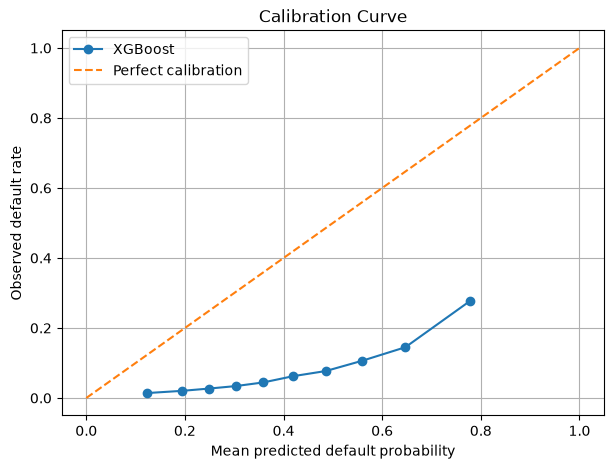

In [23]:
plt.figure(figsize=(7, 5))

plt.plot(prob_pred, prob_true, marker="o", label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted default probability")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
calibration_table = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "observed_default_rate": prob_true
})

calibration_table

,mean_predicted_probability,observed_default_rate
0,0.122147,0.013981
1,0.194754,0.020488
2,0.249282,0.026992
3,0.302643,0.033984
4,0.358618,0.044383
5,0.419835,0.062439
6,0.485759,0.077073
7,0.559353,0.106341
8,0.646995,0.145041
9,0.777475,0.276540


In [25]:
os.makedirs("../outputs", exist_ok=True)

calibration_table.to_csv("../outputs/calibration_table.csv", index=False)

In [26]:
os.path.exists("../outputs/calibration_table.csv")

True

In [27]:
def threshold_decision(probability, approve_threshold, reject_threshold):
    """
    Assigns a credit decision based on default probability thresholds.
    """
    if probability <= approve_threshold:
        return "Approve"
    elif probability >= reject_threshold:
        return "Reject"
    else:
        return "Manual Review"

In [28]:
threshold_df = pd.DataFrame({
    "actual_default": y_test.values,
    "default_probability": y_proba
})

threshold_df.head()

,actual_default,default_probability
0,0,0.382572
1,0,0.308149
2,0,0.793484
3,0,0.417316
4,0,0.476246


In [29]:
approve_threshold = 0.20
reject_threshold = 0.50

threshold_df["decision"] = threshold_df["default_probability"].apply(
    lambda p: threshold_decision(
        p,
        approve_threshold=approve_threshold,
        reject_threshold=reject_threshold
    )
)

threshold_df["decision"].value_counts(normalize=True)

decision
Manual Review    0.511682
Reject           0.329122
Approve          0.159195
Name: proportion, dtype: float64

In [30]:
scenario_analysis = threshold_df.groupby("decision").agg(
    applicants=("actual_default", "count"),
    defaults=("actual_default", "sum"),
    default_rate=("actual_default", "mean"),
    avg_default_probability=("default_probability", "mean")
).reset_index()

scenario_analysis

,decision,applicants,defaults,default_rate,avg_default_probability
0,Approve,9791,154,0.015729,0.144825
1,Manual Review,31470,1413,0.044900,0.342762
2,Reject,20242,3398,0.167869,0.647922


In [31]:
scenarios = []

approve_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]
reject_thresholds = [0.40, 0.50, 0.60, 0.70]

for approve_t in approve_thresholds:
    for reject_t in reject_thresholds:
        
        if approve_t >= reject_t:
            continue
        
        temp = threshold_df.copy()
        
        temp["decision"] = temp["default_probability"].apply(
            lambda p: threshold_decision(
                p,
                approve_threshold=approve_t,
                reject_threshold=reject_t
            )
        )
        
        total_applicants = len(temp)
        
        approve_group = temp[temp["decision"] == "Approve"]
        review_group = temp[temp["decision"] == "Manual Review"]
        reject_group = temp[temp["decision"] == "Reject"]
        
        scenarios.append({
            "approve_threshold": approve_t,
            "reject_threshold": reject_t,
            "approval_rate": len(approve_group) / total_applicants,
            "manual_review_rate": len(review_group) / total_applicants,
            "reject_rate": len(reject_group) / total_applicants,
            "approved_default_rate": approve_group["actual_default"].mean() if len(approve_group) > 0 else np.nan,
            "manual_review_default_rate": review_group["actual_default"].mean() if len(review_group) > 0 else np.nan,
            "rejected_default_rate": reject_group["actual_default"].mean() if len(reject_group) > 0 else np.nan,
            "approved_applicants": len(approve_group),
            "manual_review_applicants": len(review_group),
            "rejected_applicants": len(reject_group)
        })

scenario_results = pd.DataFrame(scenarios)

scenario_results

,approve_threshold,reject_threshold,approval_rate,manual_review_rate,reject_rate,approved_default_rate,manual_review_default_rate,rejected_default_rate,approved_applicants,manual_review_applicants,rejected_applicants
0,0.10,0.4,0.023901,0.494854,0.481245,0.007483,0.030163,0.136361,1470,30435,29598
1,0.10,0.5,0.023901,0.646977,0.329122,0.007483,0.039104,0.167869,1470,39791,20242
2,0.10,0.6,0.023901,0.776190,0.199909,0.007483,0.049457,0.210899,1470,47738,12295
3,0.10,0.7,0.023901,0.876315,0.099784,0.007483,0.060376,0.277008,1470,53896,6137
4,0.15,0.4,0.079021,0.439735,0.481245,0.011934,0.032206,0.136361,4860,27045,29598
5,0.15,0.5,0.079021,0.591857,0.329122,0.011934,0.041455,0.167869,4860,36401,20242
6,0.15,0.6,0.079021,0.721071,0.199909,0.011934,0.052178,0.210899,4860,44348,12295
7,0.15,0.7,0.079021,0.821196,0.099784,0.011934,0.063497,0.277008,4860,50506,6137
8,0.20,0.4,0.159195,0.359560,0.481245,0.015729,0.035046,0.136361,9791,22114,29598
9,0.20,0.5,0.159195,0.511682,0.329122,0.015729,0.044900,0.167869,9791,31470,20242


In [32]:
scenario_results.sort_values(
    by=["approved_default_rate", "approval_rate"],
    ascending=[True, False]
)

,approve_threshold,reject_threshold,approval_rate,manual_review_rate,reject_rate,approved_default_rate,manual_review_default_rate,rejected_default_rate,approved_applicants,manual_review_applicants,rejected_applicants
0,0.10,0.4,0.023901,0.494854,0.481245,0.007483,0.030163,0.136361,1470,30435,29598
1,0.10,0.5,0.023901,0.646977,0.329122,0.007483,0.039104,0.167869,1470,39791,20242
2,0.10,0.6,0.023901,0.776190,0.199909,0.007483,0.049457,0.210899,1470,47738,12295
3,0.10,0.7,0.023901,0.876315,0.099784,0.007483,0.060376,0.277008,1470,53896,6137
4,0.15,0.4,0.079021,0.439735,0.481245,0.011934,0.032206,0.136361,4860,27045,29598
5,0.15,0.5,0.079021,0.591857,0.329122,0.011934,0.041455,0.167869,4860,36401,20242
6,0.15,0.6,0.079021,0.721071,0.199909,0.011934,0.052178,0.210899,4860,44348,12295
7,0.15,0.7,0.079021,0.821196,0.099784,0.011934,0.063497,0.277008,4860,50506,6137
8,0.20,0.4,0.159195,0.359560,0.481245,0.015729,0.035046,0.136361,9791,22114,29598
9,0.20,0.5,0.159195,0.511682,0.329122,0.015729,0.044900,0.167869,9791,31470,20242


In [33]:
balanced_scenarios = scenario_results[
    (scenario_results["approved_default_rate"] <= 0.03) &
    (scenario_results["approval_rate"] >= 0.20)
].sort_values(
    by=["approval_rate", "approved_default_rate"],
    ascending=[False, True]
)

balanced_scenarios

,approve_threshold,reject_threshold,approval_rate,manual_review_rate,reject_rate,approved_default_rate,manual_review_default_rate,rejected_default_rate,approved_applicants,manual_review_applicants,rejected_applicants
16,0.30,0.4,0.345934,0.172821,0.481245,0.021997,0.043372,0.136361,21276,10629,29598
17,0.30,0.5,0.345934,0.324943,0.329122,0.021997,0.054991,0.167869,21276,19985,20242
18,0.30,0.6,0.345934,0.454157,0.199909,0.021997,0.068166,0.210899,21276,27932,12295
19,0.30,0.7,0.345934,0.554282,0.099784,0.021997,0.082048,0.277008,21276,34090,6137
12,0.25,0.4,0.251142,0.267613,0.481245,0.018840,0.038763,0.136361,15446,16459,29598
13,0.25,0.5,0.251142,0.419736,0.329122,0.018840,0.049429,0.167869,15446,25815,20242
14,0.25,0.6,0.251142,0.548949,0.199909,0.018840,0.061637,0.210899,15446,33762,12295
15,0.25,0.7,0.251142,0.649074,0.099784,0.018840,0.074499,0.277008,15446,39920,6137


In [34]:
scenario_results.to_csv("../outputs/threshold_simulation_results.csv", index=False)

In [35]:
os.path.exists("../outputs/threshold_simulation_results.csv")

True

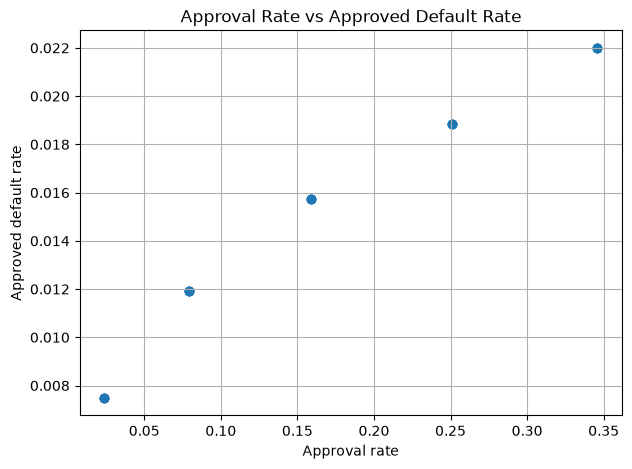

In [36]:
plt.figure(figsize=(7, 5))

plt.scatter(
    scenario_results["approval_rate"],
    scenario_results["approved_default_rate"]
)

plt.xlabel("Approval rate")
plt.ylabel("Approved default rate")
plt.title("Approval Rate vs Approved Default Rate")
plt.grid(True)

plt.show()

In [37]:
recommended_scenario = balanced_scenarios.head(1)

recommended_scenario

,approve_threshold,reject_threshold,approval_rate,manual_review_rate,reject_rate,approved_default_rate,manual_review_default_rate,rejected_default_rate,approved_applicants,manual_review_applicants,rejected_applicants
16,0.3,0.4,0.345934,0.172821,0.481245,0.021997,0.043372,0.136361,21276,10629,29598


## Model calibration and threshold simulation results

This notebook evaluates the calibration and decision threshold behavior of the XGBoost credit risk model.

The ROC-AUC score measures how well the model ranks applicants by risk, while the Brier score evaluates the quality of the predicted probabilities. A calibration curve was used to compare predicted default probabilities against observed default rates.

A threshold simulation was then performed to test different approval and rejection cutoffs. Each scenario reports approval rate, manual review rate, rejection rate, and observed default rates for each decision group.

This step connects model predictions to business decision-making. Instead of using fixed arbitrary thresholds, the Credit Intelligence Engine can compare multiple decision policies and select thresholds based on risk tolerance, approval targets, and operational capacity for manual review.
